# Les statistiques multivariées avec Pandas

## Du mono vers le multi : pourquoi ?

Dans le notebook précédent (`04-summarize-data`), on a regardé chaque variable **isolément** (analyse *univariée*). C'était déjà riche en informations. Mais la vraie valeur d'un dataset vient de ses **relations entre variables**.

> **L'analogie à garder en tête :** imaginez un détective qui essaie de comprendre un crime. Regarder chaque indice isolément (empreinte, mobile, alibi) lui donne des informations partielles. Ce qui fait avancer l'enquête, c'est de **croiser** ces indices : *« la personne qui avait le mobile était-elle sur les lieux au bon moment ? »*. C'est exactement ce que fait l'**analyse multivariée** : elle croise les variables pour révéler des patterns invisibles en univarié.

**Les questions types de l'analyse multivariée :**
- *« Est-ce que X change quand Y change ? »* → corrélation.
- *« Est-ce que la distribution de X est différente selon les groupes de Y ? »* → comparaison par catégorie.
- *« Quelles variables sont **redondantes** (apportent la même information) ? »* → risque de multicolinéarité.
- *« Quelles variables sont les plus **liées à la cible** ? »* → premières candidates pour être de bonnes features.

**Pourquoi ça compte en ML ?**
1. **Identifier les features prédictives** : une variable fortement corrélée à la cible est probablement un bon prédicteur (attention, ça ne garantit rien).
2. **Détecter les redondances** : deux features quasi identiques gonflent inutilement le modèle et peuvent déstabiliser certains algorithmes (régression linéaire, notamment).
3. **Repérer le data leakage** : une feature trop corrélée à la cible cache souvent une fuite d'information.
4. **Guider le feature engineering** : une relation non-linéaire entre deux variables peut suggérer une transformation.

## Le dataset Titanic (rappel)

Nous allons nous appuyer sur un cas de data science classique : le [naufrage du Titanic](https://fr.wikipedia.org/wiki/Naufrage_du_Titanic).

Le dataset est composé de plusieurs colonnes :

| Colonne | Description |
|---|---|
| `pclass` | Classe de voyage (1 = 1ère ; 2 = 2nde ; 3 = 3ème) |
| `name` | Nom |
| `sex` | Sexe |
| `age` | Âge |
| `sibsp` | Nombre de frères/sœurs/épouse à bord |
| `parch` | Nombre de parents/enfants à bord |
| `ticket` | Numéro de ticket |
| `fare` | Montant du billet |
| `cabin` | Numéro de cabine |
| `embarked` | Port d'embarquement (C = Cherbourg ; Q = Queenstown ; S = Southampton) |
| `boat` | Numéro de barque (si survivant) |
| `body` | Numéro de corps (si décédé) |
| `home.dest` | Destination |

**Cible à prédire :** `survived` → 0 = Non, 1 = Oui.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

from sklearn.datasets import fetch_openml

In [2]:
titanic = fetch_openml("titanic", version=1, as_frame=True, parser="auto")
titanic1 = titanic.data
survived = titanic.target

In [3]:
titanic1.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Suppression des variables inutiles pour la phase d'exploration

Comme dans le notebook précédent, on nettoie d'abord :

- **`cabin`, `home.dest`** : trop de valeurs manquantes → ignorées en phase exploratoire.
- **`boat`, `body`** : ⚠️ **data leakage** — elles encodent directement la target (survivant / décédé). **À supprimer absolument.**
- **`name`, `ticket`** : haute cardinalité, non exploitables en l'état.

In [4]:
titanic2 = titanic1.drop(["cabin", "home.dest", "boat", "body", "name", "ticket"], axis=1)
titanic2.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.0000,0,0,211.3375,S
1,1,male,0.9167,1,2,151.5500,S
2,1,female,2.0000,1,2,151.5500,S
3,1,male,30.0000,1,2,151.5500,S
4,1,female,25.0000,1,2,151.5500,S


## Analyse multivariée

On va croiser les variables entre elles pour repérer des patterns. Trois combinaisons possibles :

| Type 1 | Type 2 | Outil |
|---|---|---|
| Catégorielle | Numérique | **Boxplot par groupe** (`sns.boxplot(x=cat, y=num)`), tableau des moyennes |
| Catégorielle | Catégorielle | **Tableau croisé** (`pd.crosstab`), heatmap, barplot groupé |
| Numérique | Numérique | **Scatter plot**, **coefficient de corrélation**, heatmap de corrélation |

On va parcourir ces trois cas en les appliquant au Titanic.

### Relation entre variables qualitatives et variables numériques

**Le problème :** on veut comparer la distribution d'une variable **numérique** (`age`, `fare`) selon les **catégories** d'une autre variable (`embarked`, `sex`, `survived`).

**La solution classique :** tracer un **boxplot par catégorie**. On obtient plusieurs boîtes à moustaches côte à côte et on compare leurs positions (médianes), leurs tailles (dispersions) et leurs outliers.

> **Pourquoi c'est instructif :** deux groupes peuvent avoir **la même moyenne** mais des distributions totalement différentes. Ou des **médianes très proches** mais des dispersions opposées. Un boxplot par catégorie révèle tout ça en un coup d'œil.

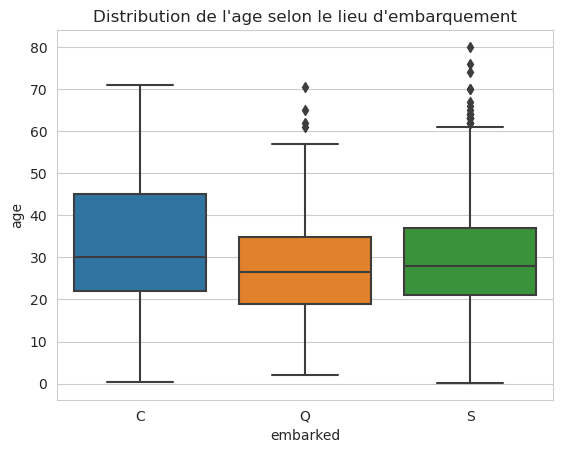

In [5]:
ax = sns.boxplot(data=titanic2, x="embarked", y="age")
ax.set_title("Distribution de l'age selon le lieu d'embarquement");

**Observation :** l'**âge médian** des voyageurs ayant embarqué à **Cherbourg (C)** est plus élevé que celui des autres ports.

> **Interprétation métier :** Cherbourg était un des ports d'embarquement pour la 1ère classe du Titanic (les voyageurs riches et plus âgés montaient à Cherbourg, notamment parce que la France était un point de départ pour les Américains fortunés rentrant chez eux). Southampton était plus « populaire », Queenstown accueillait surtout les émigrants irlandais souvent plus jeunes.
>
> **Leçon :** l'EDA multivariée révèle ici une **structure sociale historique** cachée dans les données. C'est exactement ce qu'on cherche — et ce que la statistique univariée n'aurait jamais révélé.

**Étudier le lien variable numérique ↔ cible** est une étape clé en feature selection. Une forte différence de distribution entre les classes de la cible signale une variable **potentiellement prédictrice**.

> **L'intuition :** si la distribution de `fare` chez les survivants est *très différente* de celle chez les non-survivants, alors `fare` « sait quelque chose » sur la survie. C'est précisément ce que les algorithmes de ML vont exploiter.

(0.0, 140.0)

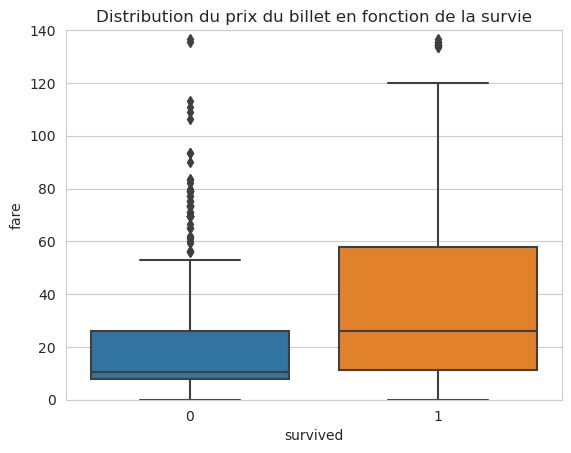

In [6]:
ax = sns.boxplot(x=survived, y=titanic2["fare"])
ax.set_title("Distribution du prix du billet en fonction de la survie")
ax.set_ylim((0, 140))

**Observation :** les survivants avaient payé un prix **nettement plus élevé** que ceux qui n'ont pas survécu.

> **Pourquoi ?** Le prix du billet est fortement corrélé à la classe de voyage (`pclass`), et les passagers de **1ère classe** avaient des cabines plus proches du pont supérieur, donc un accès plus rapide aux canots de sauvetage. Le `fare` encode une **information sociale** qui s'est traduite par un **avantage physique** en cas d'évacuation.
>
> **Leçon ML :** `fare` est déjà identifiée comme une bonne feature pour prédire la survie, sans avoir entraîné le moindre modèle. C'est la **force de l'EDA** : elle guide le feature engineering avant la modélisation.

### Liens entre variables qualitatives

Pour croiser **deux variables catégorielles**, on utilise un **tableau croisé** (*cross-tab* ou *contingency table*). `pd.crosstab()` compte combien d'observations tombent dans chaque combinaison (*cat1*, *cat2*).

> **Mental model :** c'est l'équivalent en Python du **tableau croisé dynamique** d'Excel. On choisit une variable en ligne, une en colonne, et on compte les occurrences de chaque cellule.

In [7]:
ctab = pd.crosstab(titanic2["pclass"], survived, margins=True)
ctab

survived,0,1,All
pclass,,,
1,123,200,323
2,158,119,277
3,528,181,709
All,809,500,1309


**Les effectifs bruts ne sont pas toujours parlants** — surtout si les groupes sont de tailles très différentes. Ce qui compte vraiment en ML, c'est le **pourcentage** : *« parmi les 1ère classe, quel pourcentage a survécu ? »*.

On transforme donc chaque ligne pour que les valeurs expriment des proportions par classe.

In [8]:
ctab_pclass = ctab.apply(lambda x: x / x["All"] * 100, axis=1)
ctab_pclass.round(2)

survived,0,1,All
pclass,,,
1,38.08,61.92,100.0
2,57.04,42.96,100.0
3,74.47,25.53,100.0
All,61.80,38.20,100.0


**La heatmap** est une excellente manière de **visualiser un tableau croisé** : la couleur code l'intensité, on voit immédiatement les cases « chaudes » (nombre élevé) et « froides ».

> **Astuce de lecture :** on veut voir émerger des **contrastes** — si toutes les cases sont de la même couleur, la variable n'a pas d'effet sur la cible.

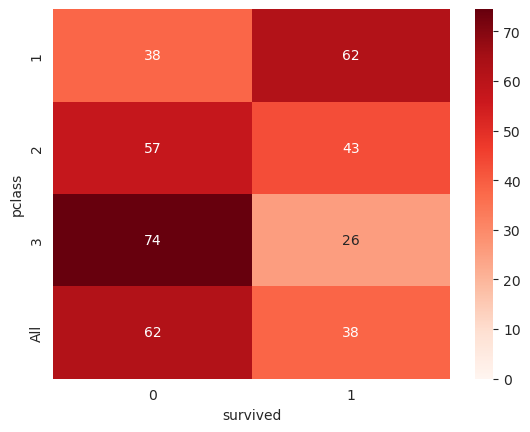

In [9]:
sns.heatmap(ctab_pclass[["0", "1"]], vmin=0, annot=True, cmap="Reds");

**`sns.countplot`** est une alternative au crosstab pour visualiser la même information : au lieu d'afficher les chiffres dans une table, on dessine **un barplot groupé**. Avec `hue='survived'`, chaque catégorie se divise en deux barres (une par classe cible).

> **Quand l'utiliser ?** Quand on veut voir **les effectifs absolus** en plus des proportions. Un barplot est souvent plus immédiatement parlant qu'une heatmap pour un public non technique.

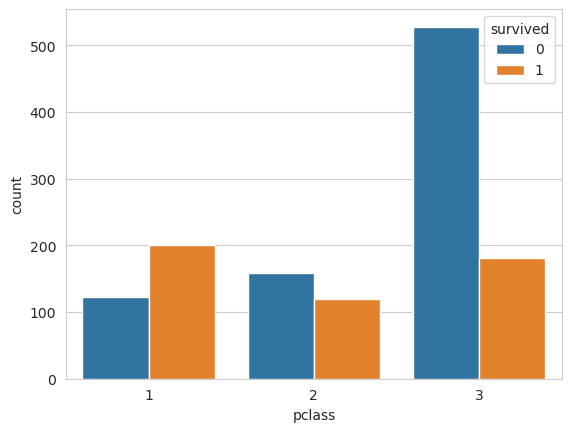

In [10]:
titanic2_target = titanic2.copy()
titanic2_target["survived"] = survived.astype(int)
ax = sns.countplot(x="pclass", hue="survived", data=titanic2_target)

## Recherche de corrélations entre variables

**L'idée :** mesurer à quel point **deux variables varient ensemble**. Plutôt que regarder des graphiques un à un, on calcule un **nombre** entre -1 et +1 qui résume la force et le sens de la relation. C'est le **coefficient de corrélation**.

### Interpréter un coefficient de corrélation

| Valeur | Signification |
|---|---|
| **+1** | Relation parfaite et positive (quand X monte, Y monte proportionnellement) |
| **0** | Pas de relation (linéaire) détectée |
| **-1** | Relation parfaite et négative (quand X monte, Y descend) |

### Pourquoi c'est utile en ML

En pratique, on calcule une **matrice de corrélation** (toutes les paires de variables en même temps) pour répondre à deux questions :

1. **Quelles variables sont corrélées avec la cible ?** → ce sont les **candidates fortes** pour être de bonnes features (toujours à vérifier, mais c'est un bon point de départ).
2. **Quelles variables sont corrélées entre elles ?** → si deux features sont **très corrélées** (ex : 0,95), elles apportent presque la même information. C'est une **redondance** qui peut :
   - gonfler inutilement la dimensionnalité ;
   - **déstabiliser** certains algorithmes (régression linéaire → multicolinéarité, KNN → biais d'échelle).

   Dans ces cas, on peut en supprimer une, ou les combiner (PCA, moyennes…).

> **⚠️ Corrélation ≠ causalité.** Deux variables peuvent varier ensemble sans qu'une cause l'autre. L'exemple classique : les ventes de glace et les noyades sont corrélées — pas parce que la glace cause la noyade, mais parce que **l'été est un facteur commun caché**. Un coefficient de corrélation **détecte** un pattern, il ne l'explique pas.

### Coefficient de corrélation linéaire de **Pearson**

C'est la corrélation **la plus connue et la plus utilisée**. Elle mesure la force d'une **relation linéaire** entre deux variables.

**Définition en une phrase :** Pearson mesure les relations **linéaires** entre deux variables quantitatives continues supposées normalement distribuées.

**À savoir avant de s'en servir :** il faut être **extrêmement prudent** en utilisant la corrélation linéaire. Un coefficient proche de 0 ne signifie **pas** qu'il n'y a pas de relation entre les variables — ça signifie seulement qu'il n'y a pas de relation **linéaire**. Deux variables peuvent être fortement liées (ex : $Y = X^2$) avec un coefficient de Pearson très faible.

### Grille d'interprétation

| Valeur | Sens |
|---|---|
| **+1** | Relation linéaire positive parfaite (les points sont sur une droite montante) |
| **0** | Pas de **relation linéaire** détectée |
| **-1** | Relation linéaire négative parfaite (droite descendante) |

### Conditions d'utilisation

- Variables **quantitatives continues**.
- Relation **linéaire** présumée.
- Données **sans outliers marqués** (Pearson est très sensible aux valeurs extrêmes, comme la moyenne et l'écart-type).

### Illustration visuelle

La figure ci-dessous montre plusieurs cas. **Remarquez la ligne du bas** : ce sont des relations très nettes (parabole, X, cercle…) avec un coefficient de Pearson de **0**. C'est le piège à retenir.

![Pearson](https://upload.wikimedia.org/wikipedia/commons/0/02/Correlation_examples.png)

### La formule (pour les curieux)

$
\Large{
r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
}
$

**Décodage :**
- Le numérateur $\sum (X_i - \bar{X})(Y_i - \bar{Y})$ est **positif** quand les deux écarts ont le même signe (les deux valeurs sont soit toutes deux au-dessus de leur moyenne, soit toutes deux en-dessous) et **négatif** sinon. C'est la **covariance** (non normalisée).
- Le dénominateur normalise par les écarts-types pour que le résultat soit borné entre -1 et +1 (sans unité).

**En langage courant :** Pearson mesure à quel point **X et Y s'écartent de leurs moyennes de manière synchronisée**. Si l'écart est toujours dans le même sens → corrélation positive. Si toujours dans le sens opposé → négative.

In [11]:
# Coefficient de Pearson
corr_pearson = titanic2.corr(numeric_only=True)
corr_pearson

,pclass,age,sibsp,parch,fare
pclass,1.000000,-0.408106,0.060832,0.018322,-0.558629
age,-0.408106,1.000000,-0.243699,-0.150917,0.178739
sibsp,0.060832,-0.243699,1.000000,0.373587,0.160238
parch,0.018322,-0.150917,0.373587,1.000000,0.221539
fare,-0.558629,0.178739,0.160238,0.221539,1.000000


**Visualisation avec une `heatmap` :** la matrice de corrélation devient un damier coloré. Rouge foncé = corrélation positive forte, bleu foncé = corrélation négative forte, blanc/pâle = proche de 0.

> **Le réflexe de lecture :**
> - **La diagonale est toujours à 1** (une variable est parfaitement corrélée avec elle-même).
> - **La matrice est symétrique** : `corr(X, Y) = corr(Y, X)` — donc la moitié suffit à lire.
> - On cherche d'abord les **cases très colorées hors diagonale** (relations fortes à explorer) et les **lignes/colonnes de la target** (futures bonnes features).

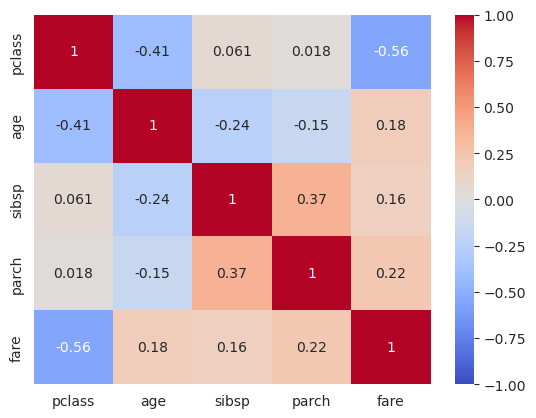

In [12]:
sns.heatmap(corr_pearson, annot=True, vmin=-1, cmap="coolwarm");

### Limites de Pearson

Le coefficient de Pearson fait des **hypothèses fortes** sur les données, souvent violées en pratique :

- Il s'applique sur des **variables continues** (pas ordinales, pas catégorielles).
- **Linéarité** : 1 ou -1 correspondent à une relation **strictement linéaire** — toute courbure sera sous-estimée.
- **Normalité** : les données devraient suivre une distribution gaussienne.
- **Homoscédasticité** : les données sont uniformément dispersées autour de la droite de régression (la variance ne change pas avec X).

### Sur le Titanic, est-ce que Pearson convient ?

**Non, pas vraiment** :
- Plusieurs variables sont **ordinales** (`pclass`) ou discrètes avec peu de valeurs (`sibsp`, `parch`).
- L'analyse univariée du notebook précédent a montré que `fare` a une **longue traîne à droite** (skew positif) → **pas gaussien du tout**.

**Conclusion :** le coefficient de Pearson **n'est pas le plus adapté** ici. On va utiliser **Spearman** (ou Kendall) qui sont plus robustes à ces problèmes.

### Corrélation de **Spearman**

**L'idée :** Spearman ne regarde pas les **valeurs** elles-mêmes, mais leurs **rangs** (qui est le plus petit, le deuxième, le troisième…). Il calcule ensuite la corrélation de Pearson sur les rangs.

> **Mental model :** Pearson demande *« est-ce que X et Y sont sur une droite ? »*. Spearman demande seulement *« est-ce que X et Y montent et descendent dans le même ordre ? »*.

**Conséquence :** la relation doit être **monotone** (strictement croissante ou décroissante), mais **pas forcément linéaire**. $Y = X^2$ sur des valeurs positives est parfaitement monotone → Spearman = 1 ; Pearson serait inférieur à 1.

### Caractéristiques

- S'applique entre des **variables continues OU ordinales** (nettement plus flexible que Pearson).
- **Pas d'hypothèse de normalité**.
- **Robuste aux outliers** : comme on travaille sur les rangs, une valeur extrême devient juste « la plus grande » — elle n'a plus l'effet démesuré qu'elle aurait sur la moyenne.

### Interprétation

- **+1** : relation monotone **croissante** parfaite.
- **-1** : relation monotone **décroissante** parfaite.
- Les valeurs intermédiaires se lisent comme Pearson : plus proche de ±1, plus forte.

### Avantages pour nous (Titanic)

- Fonctionne sur `pclass` (ordinale).
- Pas perturbé par la traîne de `fare`.
- Robuste aux outliers du dataset.

**C'est donc notre choix par défaut pour ce dataset.**

In [13]:
corr_spearman = titanic2.corr("spearman", numeric_only=True)

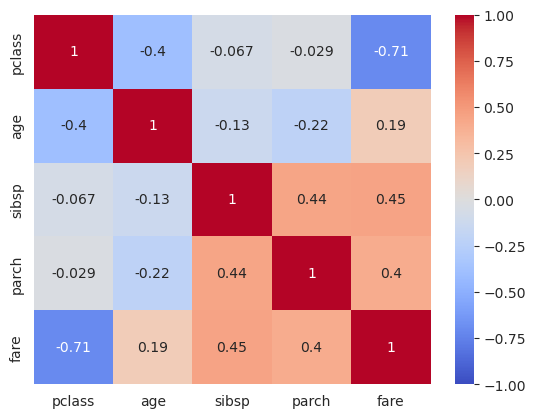

In [14]:
sns.heatmap(corr_spearman, annot=True, vmin=-1, cmap="coolwarm");

### Corrélation de **Kendall**

**L'idée :** Kendall compte le nombre de **paires concordantes** (pour lesquelles les deux variables augmentent ou diminuent ensemble) et de **paires discordantes** (où l'une augmente tandis que l'autre diminue), et calcule leur différence normalisée.

> **Mental model :** on prend **toutes les paires possibles** de deux observations dans le dataset. Pour chaque paire, on regarde si `X` et `Y` « vont dans le même sens » ou dans des sens opposés. Kendall mesure **la proportion de paires qui vont dans le bon sens**.

### Caractéristiques

- Adapté aux **variables ordinales**.
- **Plus conservateur** que Spearman : ses estimations sont généralement plus faibles en valeur absolue (ce qui ne veut pas dire qu'elles sont « moins bonnes » — juste qu'elles pénalisent plus certains cas).
- **Plus robuste aux ex-aequos** (valeurs identiques) que Spearman.
- **Adapté aux petits échantillons** (le p-value est mieux contrôlé).

### Cas d'usage

- Données **ordinales** (rangs, scores, catégories ordonnées).
- Échantillons de **petite taille**.
- Présence **fréquente d'ex-aequos** (beaucoup de valeurs identiques).

> **En pratique :** Spearman et Kendall donnent des classements très similaires — si Spearman dit *« X est la variable la plus corrélée à Y »*, Kendall le dit presque toujours aussi. Pour un usage courant en data science, **Spearman suffit amplement**. On sort Kendall si on a vraiment un petit échantillon ou beaucoup d'ex-aequos.

In [15]:
corr_kendall = titanic2.corr("kendall", numeric_only=True)

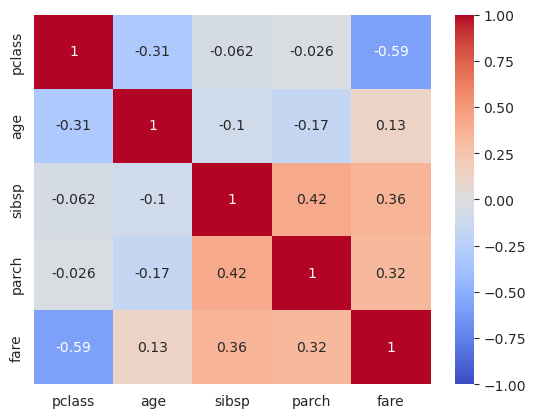

In [16]:
sns.heatmap(corr_kendall, annot=True, vmin=-1, cmap="coolwarm");

> **⚠️ Remarque importante :**
> Nous avons travaillé sur le **jeu de données complet** (train + test). Ce n'est pas un gros problème **ici** parce qu'on reste prudent dans les conclusions qu'on tire et qu'on ne fera pas reposer une décision critique sur ces observations.
>
> **Mais en général**, on isole le jeu de test **avant toute EDA** et on ne travaille que sur le train. Sinon, on introduit un **data leakage** subtil : des décisions influencées par le test (imputations, seuils, features sélectionnées) « fuitent » vers le train, et on finit par sur-estimer la performance du modèle.

### Comparaison des trois méthodes

| Critère | **Pearson** | **Spearman** | **Kendall** |
|:---:|:---:|:---:|:---:|
| **Type de relation** | Linéaire | Monotone | Monotone |
| **Hypothèses** | Normalité, linéarité | Aucune | Aucune |
| **Variables** | Continues | Continues ou ordinales | Continues ou ordinales |
| **Sensibilité aux outliers** | Forte | Faible | Faible |
| **Sensibilité aux ex-aequos** | Modérée | Modérée | **Faible** |
| **Puissance statistique** | Élevée (si hypothèses OK) | Moyenne | Faible (petits échantillons) |

### Comment choisir ?

- **Pearson** : relation clairement linéaire + données normales + pas d'outliers. Cas « de labo », rare en pratique.
- **Spearman** : **le choix par défaut en data science**. Robuste, flexible, fonctionne sur la plupart des situations réelles (données non-normales, ordinales, outliers).
- **Kendall** : surtout pour **petits échantillons** ou quand il y a **beaucoup d'ex-aequos**. Un peu plus conservateur — bonne option si on veut des estimations « prudentes ».

> **Règle pratique :** commence par **Spearman**. Si les résultats sont flous ou surprenants, compare avec Pearson et Kendall — si les trois donnent des tendances similaires, l'analyse est robuste. Si elles divergent, c'est le signe que quelque chose mérite d'être investigué (non-linéarités, outliers, distributions bizarres).

## 🎯 Synthèse — l'analyse multivariée en data science

### Pourquoi c'est essentiel

Une analyse multivariée bien faite permet de :

- **Identifier les features les plus prédictives** avant d'entraîner un modèle.
- **Détecter les redondances** (variables très corrélées entre elles) qui peuvent dégrader certains algorithmes.
- **Repérer le data leakage** (une corrélation « trop belle » avec la target cache souvent une fuite).
- **Guider le feature engineering** (relations non-linéaires → créer une transformation ou une interaction).

### La démarche type

1. **Croiser chaque feature avec la target** (boxplot, crosstab, corrélation) → repérer les plus prédictives.
2. **Matrice de corrélation des features entre elles** (Spearman de préférence) → repérer les redondances.
3. **Visualiser** avec des heatmaps, pairplots, boxplots groupés.
4. **Documenter les observations** : chaque pattern détecté est une hypothèse à retenir pour la phase de modélisation.

### Les pièges à connaître

- ⚠️ **Corrélation ≠ causalité**. Une corrélation est un pattern statistique, pas une explication. Pour conclure à un lien causal, il faut soit un modèle causal explicite (ex : *causal inference*), soit une expérience contrôlée (A/B test).
- ⚠️ **Pearson sur des données non-gaussiennes** : biais garanti. Préférer Spearman.
- ⚠️ **EDA sur le dataset complet** : introduit un data leakage subtil. Toujours isoler le test d'abord en production.
- ⚠️ **Oublier les relations non-linéaires** : toutes les corrélations numériques manquent les relations $Y = X^2$, $Y = \sin(X)$, etc. Un **scatter plot** reste indispensable pour détecter ces cas.
- ⚠️ **Taille d'échantillon** : sur 30 observations, une corrélation de 0.3 peut être du bruit statistique. Toujours accompagner d'un test de significativité (ou au moins d'un bon sens critique) sur les petits échantillons.

### Aller plus loin

| Outil | Pour quoi faire ? |
|---|---|
| **`sns.pairplot(df, hue='target')`** | Grille de scatter plots + histogrammes, couleurs par classe. Le « couteau suisse » de la bivariée. |
| **`sns.heatmap(df.corr('spearman'))`** | Vue synthétique des corrélations numériques. |
| **`df.groupby('cat')[num].agg(['mean','std'])`** | Stats descriptives par groupe, version tableau. |
| **`scipy.stats.chi2_contingency`** | Test statistique du $\chi^2$ pour l'indépendance entre variables catégorielles. |
| **`scipy.stats.f_oneway`** | ANOVA : *« les moyennes des groupes sont-elles significativement différentes ? »* |
| **`sklearn.feature_selection.mutual_info_classif`** | Information mutuelle : mesure la dépendance **non-linéaire** entre une feature et la target. Excellent complément aux corrélations classiques. |

### Le mot de la fin

> **L'analyse multivariée est le moment où les données commencent à raconter une histoire.** Elle transforme un tableau de chiffres en un ensemble d'hypothèses testables : *« les femmes en 1ère classe ont eu plus de chances de survivre »*, *« le prix du billet est un proxy du statut social »*, *« `sibsp` et `parch` ensemble capturent la taille de la famille »*. Chacune de ces hypothèses pourra (ou non) être confirmée par la modélisation — mais c'est ici, pendant l'EDA, qu'elles naissent.